# Análise Exploratória

### Importando bibliotecas e lendo os dados

In [65]:
import pandas as pd
import pandas_profiling
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')

In [ ]:
df = pd.read_csv("dados_tratados.csv")

### Resumindo Dados e explorando características

In [17]:
df.shape

(1000, 11)

In [11]:
df.head()

,bus_line_id,driver_name,bus_color,bus_start_time,bus_end_time,bus_built_date,bus_route,bus_price(R$),bus_integrity,bus_company,bus_capacity
0,1,Aguistin Seivwright,#a01e15,1:18 PM,9:36 PM,2007-01-27,Flamengo-Copacabana,1401234.56,0.80,"Zulauf, King and Schowalter",38
1,2,Tedd Ailsbury,#35f91e,4:41 PM,2:51 PM,2013-05-03,Jardim Botânico-Flamengo,701234.56,0.62,"Leuschke, Zieme and Rippin",42
2,3,Orren Layus,#662b1d,3:30 AM,10:38 AM,2002-07-07,Leblon-Botafogo,590123.45,0.99,"Oberbrunner, Padberg and Dickinson",42
3,4,Cornie Rippingall,#5ec957,4:51 AM,11:01 PM,2011-07-21,Botafogo-Leme,1234567.89,0.99,Lindgren-O'Keefe,49
4,5,Corrianne Widdowson,#5a32b2,5:10 AM,1:35 PM,2015-12-07,rota não atribuída,623456.78,0.99,Zieme LLC,36


In [16]:
df.tail()

,bus_line_id,driver_name,bus_color,bus_start_time,bus_end_time,bus_built_date,bus_route,bus_price(R$),bus_integrity,bus_company,bus_capacity
995,996,Brockie Sentinella,#f818d6,2:29 PM,7:46 PM,2006-01-30,rota não atribuída,912345.67,0.95,Lindgren-Dickinson,35
996,997,Harriett Bennellick,#3e2ffe,4:08 PM,9:58 PM,2002-06-23,Barra da Tijuca-Leblon,723456.78,0.95,Zulauf and Sons,42
997,998,Jess Pack,#30eee4,4:11 AM,8:28 PM,2014-06-18,Jardim Botânico-São Conrado,667890.12,0.52,Witting-Swift,55
998,999,motorista não atribuído,#4fcd89,2:05 PM,11:19 AM,2023-04-23,Leme-São Conrado,623456.78,0.95,Tremblay and Sons,43
999,1000,Muhammad Brigstock,#4e03af,8:52 AM,6:12 AM,2012-05-14,Gávea-Centro,645678.90,0.95,Reinger LLC,43


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bus_line_id     1000 non-null   int64  
 1   driver_name     1000 non-null   object 
 2   bus_color       1000 non-null   object 
 3   bus_start_time  1000 non-null   object 
 4   bus_end_time    1000 non-null   object 
 5   bus_built_date  1000 non-null   object 
 6   bus_route       1000 non-null   object 
 7   bus_price(R$)   1000 non-null   float64
 8   bus_integrity   1000 non-null   float64
 9   bus_company     1000 non-null   object 
 10  bus_capacity    1000 non-null   int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


In [ ]:
pandas_profiling.ProfileReport(df)

In [171]:
df.describe(include='all')  # resumo estatístico geral

,count
bus_company,
Nolan LLC,3
Fahey and Sons,3
Turner Group,3
Schinner LLC,2
Harris LLC,2
...,...
Cruickshank-Schultz,1
"Rutherford, Nienow and Wolf",1
Harris-Dickens,1


In [172]:
df['bus_integrity'].mean()  # média da integridade

np.float64(0.720605)

In [173]:
df['bus_price(R$)'].median()  # mediana dos preços

1034567.89

In [174]:
df['bus_company'].value_counts()  # frequência das companhias

,count
bus_company,
Nolan LLC,3
Fahey and Sons,3
Turner Group,3
Schinner LLC,2
Harris LLC,2
...,...
Cruickshank-Schultz,1
"Rutherford, Nienow and Wolf",1
Harris-Dickens,1


In [177]:
df.groupby('bus_company')['bus_capacity'].mean().sort_values(ascending=False)

,bus_capacity
bus_company,
"Morar, McCullough and Wisoky",60.0
McGlynn Inc,60.0
Windler-Kirlin,60.0
"Mueller, Bartoletti and Stokes",60.0
Botsford-Ernser,60.0
...,...
Wiegand Group,30.0
Cassin Group,30.0
"Bins, Schinner and Kozey",30.0


### Preparação dos dados

In [23]:
df['bus_built_date'] = pd.to_datetime(df['bus_built_date'])

In [24]:
df['bus_start_time'] = pd.to_datetime(df['bus_start_time'], format='%I:%M %p').dt.time
df['bus_end_time'] = pd.to_datetime(df['bus_end_time'], format='%I:%M %p').dt.time

In [25]:
colunas_para_string = ['driver_name', 'bus_color', 'bus_route', 'bus_company']
df[colunas_para_string] = df[colunas_para_string].astype('string')

In [28]:
df.isna().sum()

,0
bus_line_id,0
driver_name,0
bus_color,0
bus_start_time,0
bus_end_time,0
bus_built_date,0
bus_route,0
bus_price(R$),0
bus_integrity,0
bus_company,0


In [30]:
df.loc[df.duplicated()]

,bus_line_id,driver_name,bus_color,bus_start_time,bus_end_time,bus_built_date,bus_route,bus_price(R$),bus_integrity,bus_company,bus_capacity


### Visualizando os dados

Text(0, 0.5, 'Frequência')

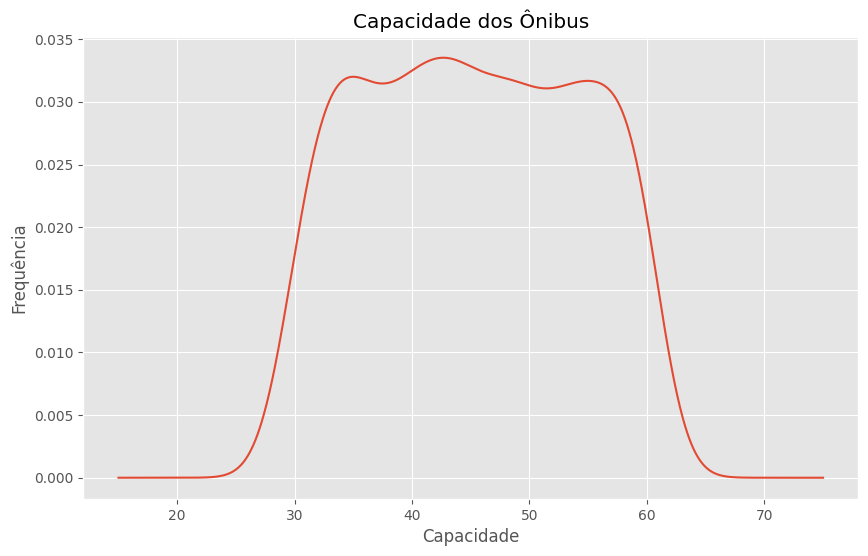

In [121]:
ax = df['bus_capacity'].plot(kind='kde', figsize=(10, 6), title = 'Capacidade dos Ônibus')
ax.set_xlabel('Capacidade')
ax.set_ylabel('Frequência')

Text(0, 0.5, 'Número de linhas')

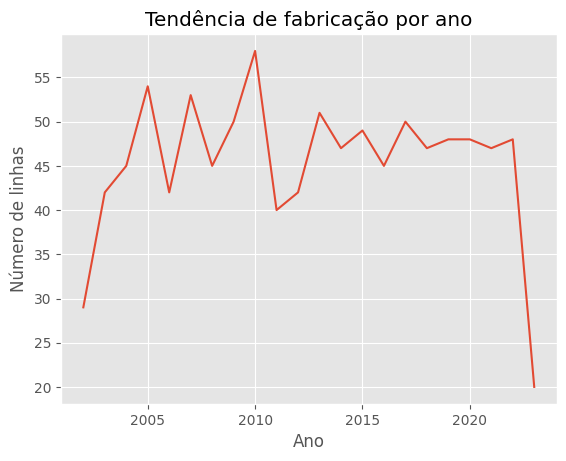

In [118]:
df['ano'] = df['bus_built_date'].dt.year
ax = df['ano'].value_counts().sort_index().plot(kind='line', title='Tendência de fabricação por ano')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de linhas')

Text(0, 0.5, 'Densidade')

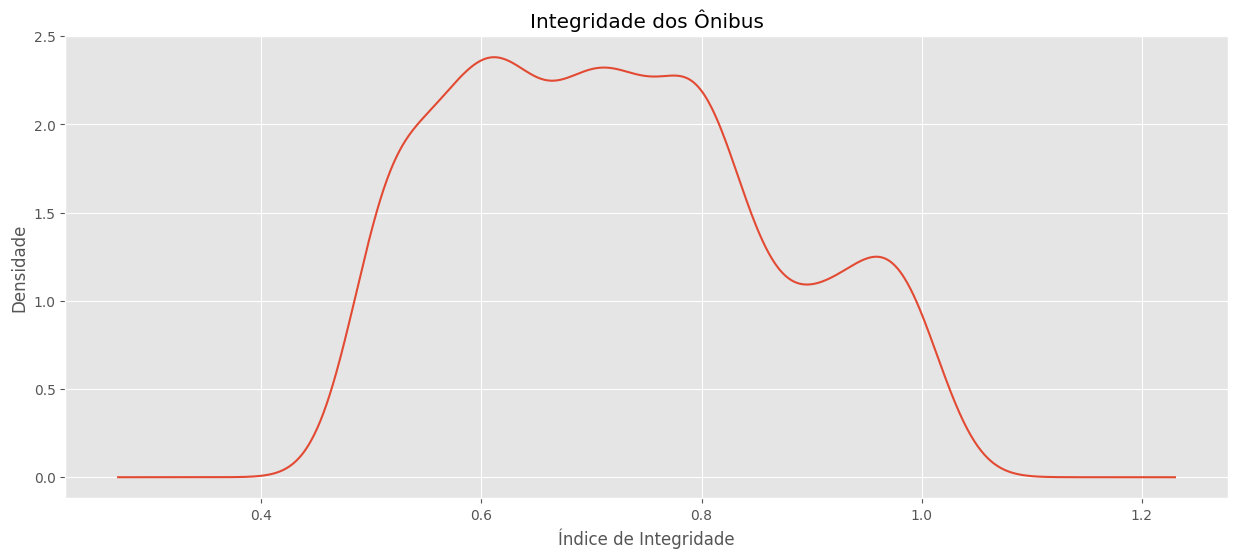

In [147]:
ax = df['bus_integrity'].plot(kind='kde', figsize=(15, 6), title = 'Integridade dos Ônibus')
ax.set_xlabel('Índice de Integridade')
ax.set_ylabel('Densidade')

Text(0, 0.5, 'Frequência')

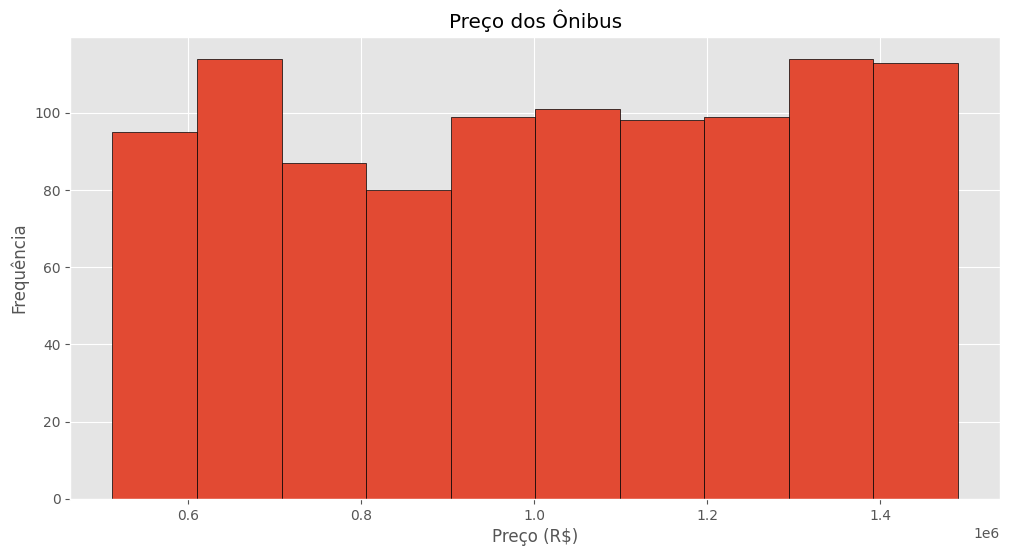

In [176]:
ax = df['bus_price(R$)'].plot(
    kind='hist',
    edgecolor='black',
    title='Preço dos Ônibus',
    figsize=(12, 6)  # opcional, só para melhorar visualização
)
ax.set_xlabel('Preço (R$)')
ax.set_ylabel('Frequência')

Text(0, 0.5, 'Número de Linhas')

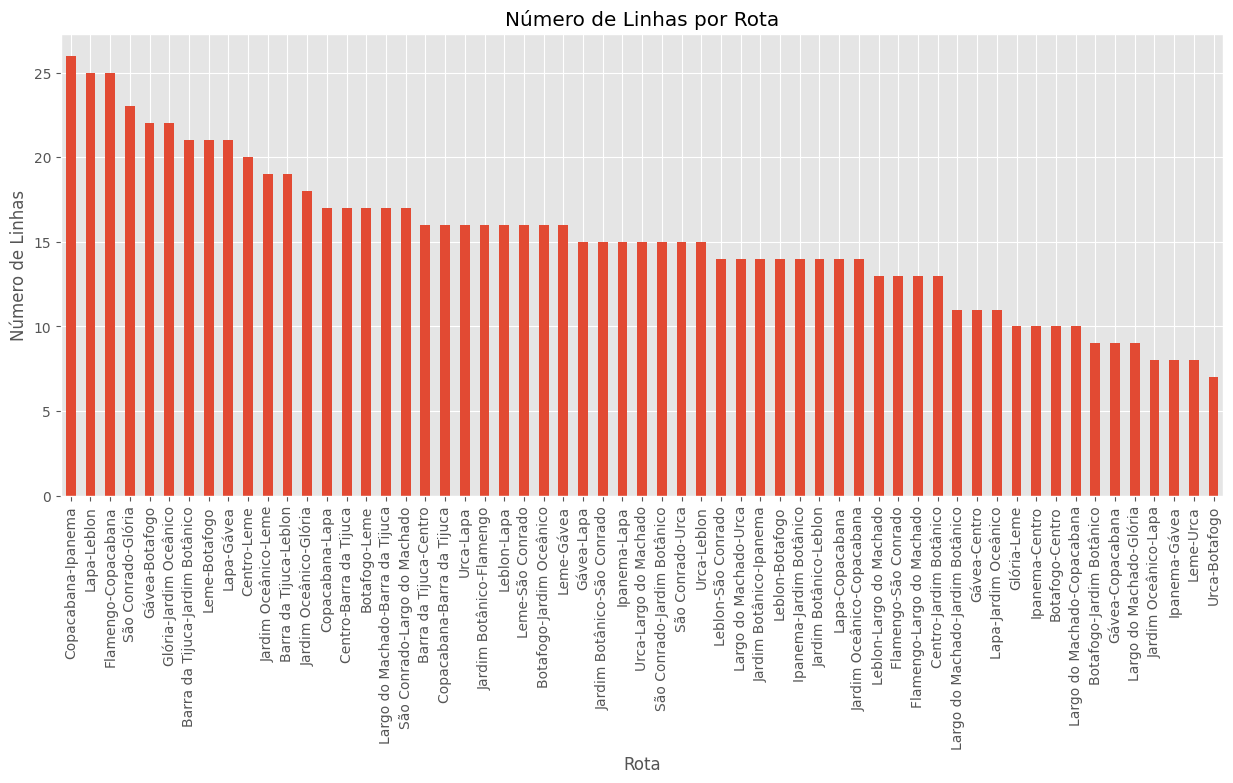

In [146]:
df_filtrado = df[df['bus_route'] != 'rota não atribuída']

ax = df_filtrado['bus_route'].value_counts().plot(kind='bar', figsize = (15, 6), title = 'Número de Linhas por Rota')
ax.set_xlabel('Rota')
ax.set_ylabel('Número de Linhas')

### Relações entre os dados

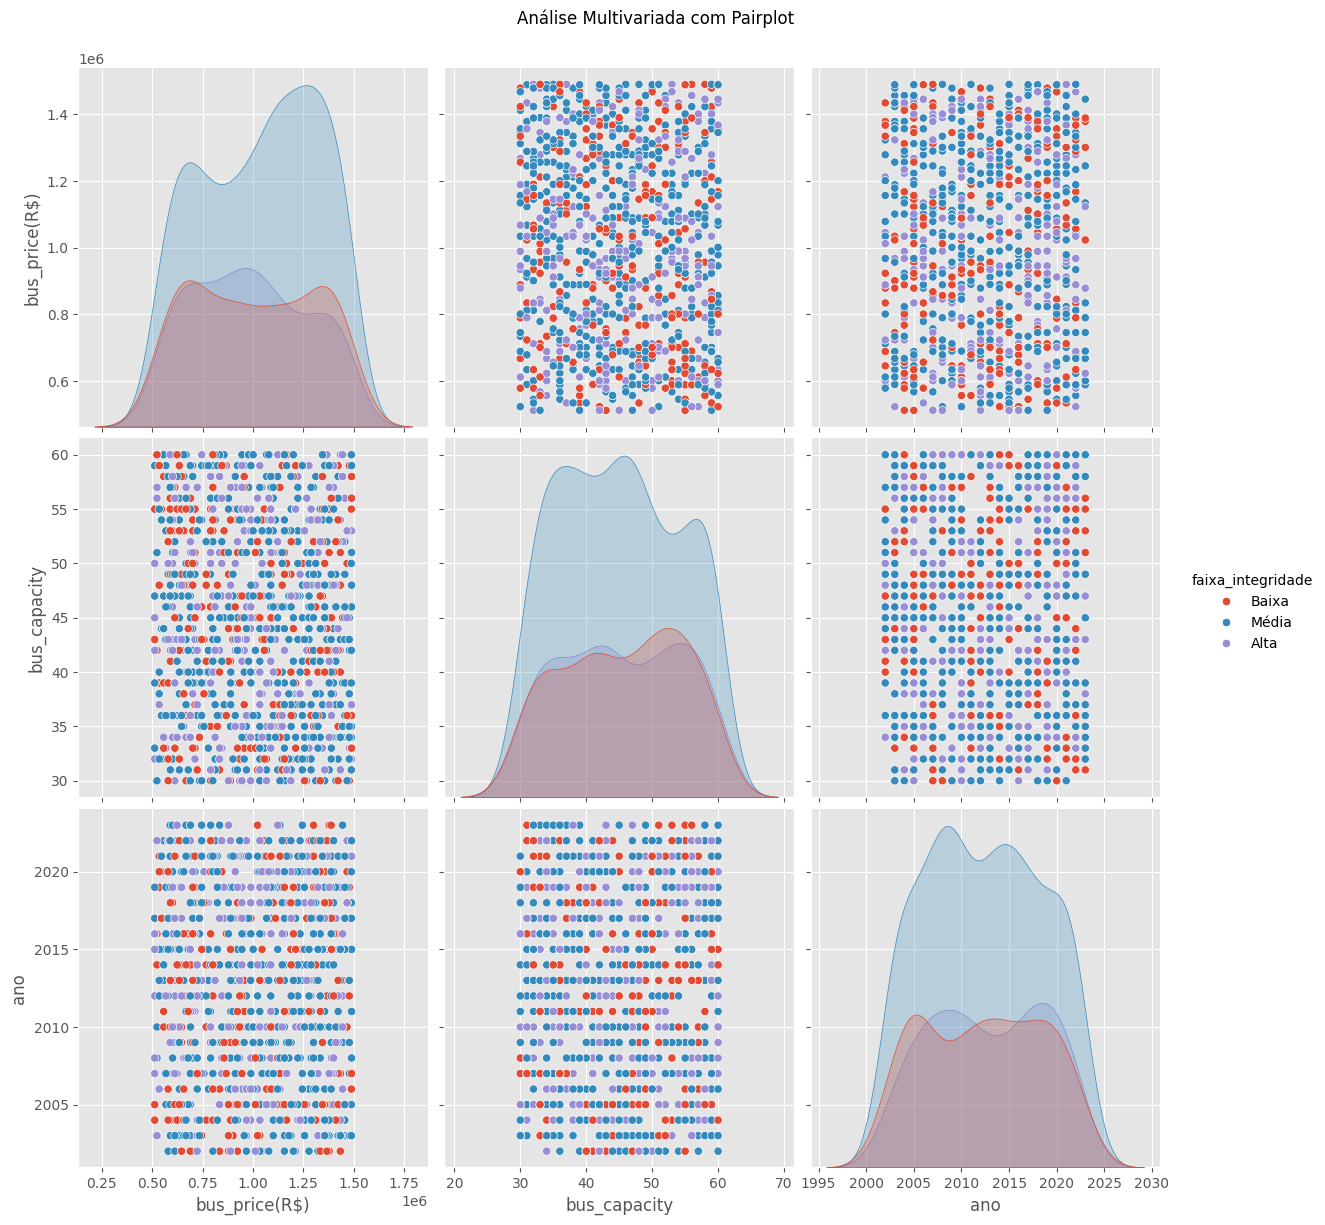

In [201]:
df['faixa_integridade'] = pd.cut(
    df['bus_integrity'],
    bins=[0, 0.6, 0.8, 1.0],
    labels=['Baixa', 'Média', 'Alta']
)

sns.pairplot(
    df,                            # amostra para legibilidade
    vars=['bus_price(R$)', 'bus_capacity', 'ano'],
    hue='faixa_integridade',
    height=4,
)
plt.suptitle('Análise Multivariada com Pairplot', y=1.02)
plt.show()

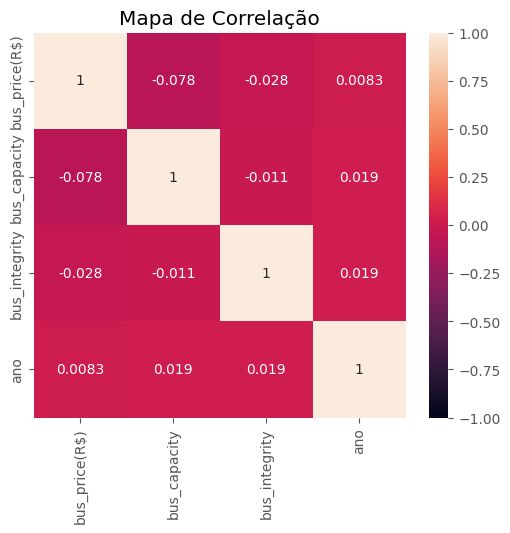

In [205]:
colunas = ['bus_price(R$)', 'bus_capacity', 'bus_integrity', 'ano']
corr = df[colunas].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1)
plt.title('Mapa de Correlação')
plt.show()

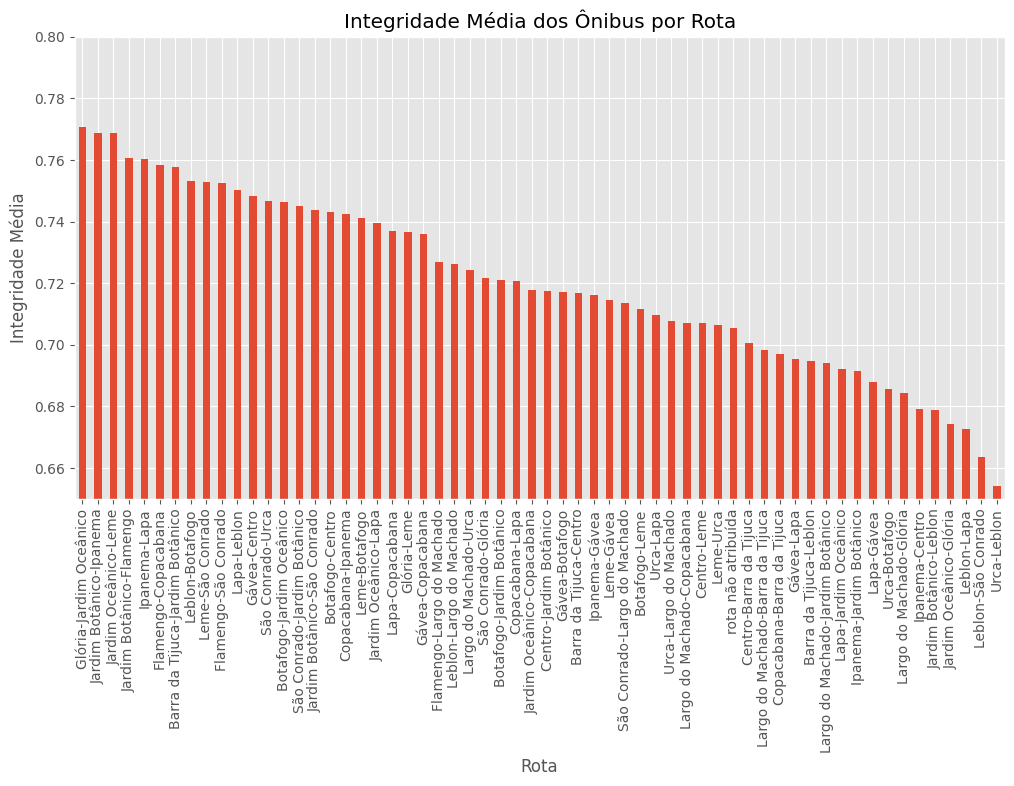

In [233]:
integrity_por_rota = df.groupby('bus_route')['bus_integrity'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
integrity_por_rota.plot(
    kind='bar',
    title='Integridade Média dos Ônibus por Rota'
)
plt.xlabel('Rota')
plt.ylabel('Integridade Média')
plt.ylim(0.65, 0.8)
plt.show()

Text(0, 0.5, 'Integridade Média')

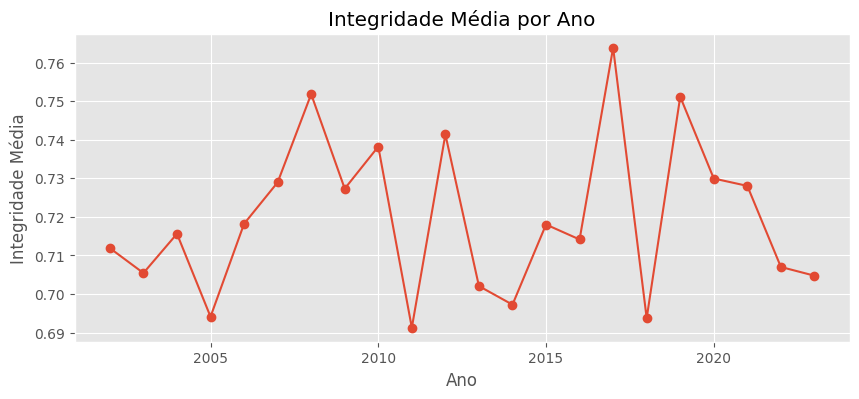

In [203]:
media_por_ano = df.groupby('ano')['bus_integrity'].mean()

plt.figure(figsize=(10,4))
media_por_ano.plot(marker='o')
plt.title('Integridade Média por Ano')
plt.xlabel('Ano')
plt.ylabel('Integridade Média')

Text(0, 0.5, 'Preço Média')

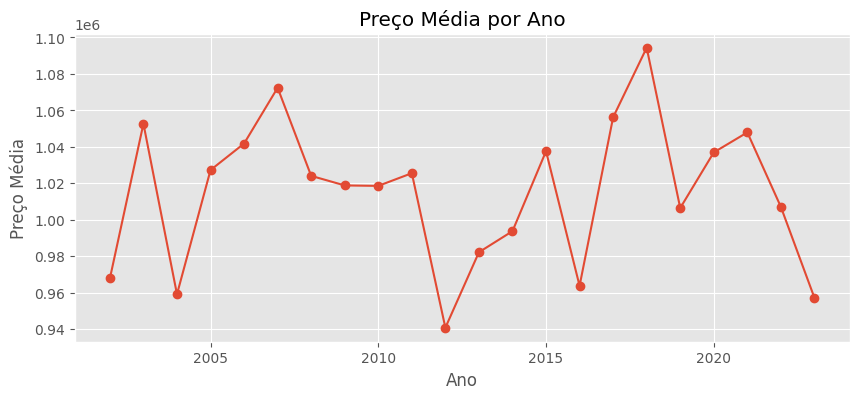

In [221]:
preço_por_ano = df.groupby('ano')['bus_price(R$)'].mean()

plt.figure(figsize=(10,4))
preço_por_ano.plot(marker='o')
plt.title('Preço Média por Ano')
plt.xlabel('Ano')
plt.ylabel('Preço Média')

Text(0, 0.5, 'Capacidade Média')

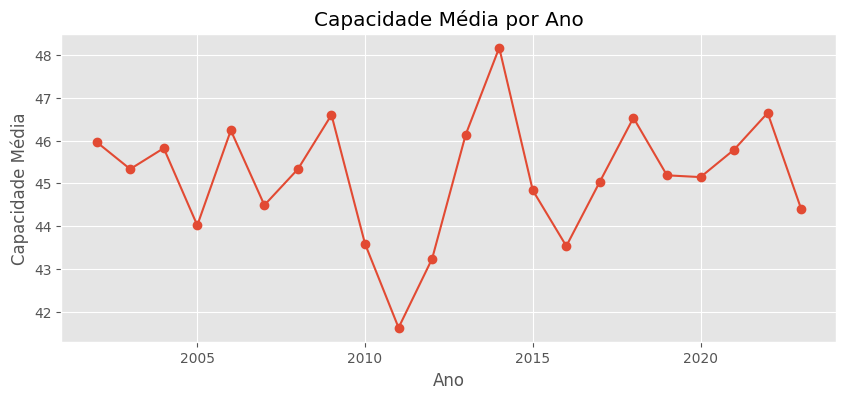

In [220]:
capacidade_por_ano = df.groupby('ano')['bus_capacity'].mean()

plt.figure(figsize=(10,4))
capacidade_por_ano.plot(marker='o')
plt.title('Capacidade Média por Ano')
plt.xlabel('Ano')
plt.ylabel('Capacidade Média')

### Insights

Insight 1: Picos Táticos de Capacidade

No gráfico “Capacidade Média por Ano”, embora a média fique em torno de 45 lugares, há um salto acentuado em 2014, quando sobe para cerca de 48 passageiros, e logo volta ao patamar anterior. Isso indica que, naquele ano, foi feito um lote específico de ônibus de maior porte – talvez para atender a um aumento temporário de demanda em determinadas rotas ou eventos – mas sem que as empresas alterassem permanentemente sua configuração de frota. Em outras palavras, a mudança foi tática, não estratégica, confirmando flexibilidade operacional sem comprometer a oferta de assentos a longo prazo.

Insight 2: Desgaste Elevado nas Rotas de Maior Operação

No gráfico “Integridade Média dos Ônibus por Rota (ordenado por número de linhas)”, observamos que as rotas mais operadas (à esquerda) não coincidem com aquelas de melhor condição. Por exemplo, rotas com alto número de linhas apresentam integridade média abaixo de várias rotas menos usadas. Isso indica que as rotas de maior frequência exigem atenção prioritária na manutenção preventiva, pois seu desgaste médio é maior justamente onde a operação é mais intensa.